# Libraries

In [542]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia
import matplotlib as mpl


In [543]:
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # or "Computer Modern"
    "font.size": 14,

    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,

    "mathtext.fontset": "cm",  # Computer Modern for LaTeX math
})

# Donwloading Data

In [570]:
query = """
SELECT
    ra, dec,
    pmra, pmdec,
    parallax,
    parallax_over_error,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag,
    ruwe,
    teff_gspphot
FROM gaiadr3.gaia_source
WHERE CONTAINS(
    POINT('ICRS', ra, dec),
    CIRCLE('ICRS', 201.69121, -47.47686, 0.25)
)=1
AND parallax > 0
AND teff_gspphot IS NOT NULL
AND parallax_over_error > 3
AND pmra IS NOT NULL
AND pmdec IS NOT NULL
AND ruwe < 1.4
"""

job = Gaia.launch_job_async(query)
results = job.get_results()
df = results.to_pandas()

df.to_csv("ASTR4991_GAIA_Omega_Centauri_Filtered_Data.csv", index=False)

INFO: Query finished. [astroquery.utils.tap.core]


# Reading Data

In [681]:
file_path_filtered = "/Users/ivarismartinez/Desktop/GAIA/ASTR4991_GAIA_Omega_Centauri_Filtered_Data.csv"

filtered_data = pd.read_csv(file_path_filtered)

print(filtered_data.columns)
print(len(filtered_data))

Index(['ra', 'dec', 'pmra', 'pmdec', 'parallax', 'parallax_over_error',
       'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'ruwe',
       'teff_gspphot'],
      dtype='object')
4637


# Part 1: Globular Cluster Membership

In [682]:
# Choosing the systematic proper motion of the cluster with the most stars (Omega Centauri) by eye
pmra_center_by_eye = -3.5
pmdec_center_by_eye = -6.5

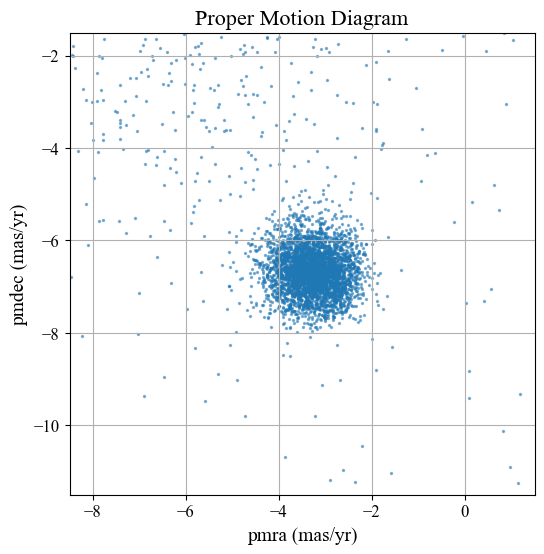

In [683]:
# Plotting the data
plt.figure(figsize=(6,6))
plt.scatter(filtered_data['pmra'], filtered_data['pmdec'], s=2, alpha=0.5)

plt.xlabel("pmra (mas/yr)")
plt.ylabel("pmdec (mas/yr)")
plt.title("Proper Motion Diagram")
plt.xlim(pmra_center_by_eye - 5, pmra_center_by_eye + 5)
plt.ylim(pmdec_center_by_eye - 5, pmdec_center_by_eye + 5)
plt.grid()

plt.savefig("Omega_Centauri_Unfiltered_Data.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("Omega_Centauri_Unfiltered_Data.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

In [684]:
# Filtering datapoints outside of the previous plot
filtered_data = filtered_data[
    (filtered_data['pmra'] > pmra_center_by_eye -5) & (filtered_data['pmra'] < pmra_center_by_eye + 5) &
    (filtered_data['pmdec'] > pmdec_center_by_eye-5) & (filtered_data['pmdec'] < pmdec_center_by_eye + 5)]

In [685]:
# Finding the actual systematic proper motion of the cluster with the most stars (Omega Centauri)
pmra_center = filtered_data['pmra'].median()
pmdec_center = filtered_data['pmdec'].median()

print(pmra_center, pmdec_center)

-3.3073522892965297 -6.63706577514974


In [686]:
# Choosing stars that are within a 1.5[] radius of the center (as stars within this radius seem to saturate the center found by the median)
radius = 1.5
mask = ((filtered_data['pmra'] - pmra_center)**2 + (filtered_data['pmdec'] - pmdec_center)**2) < radius**2
cluster_members = filtered_data[mask]


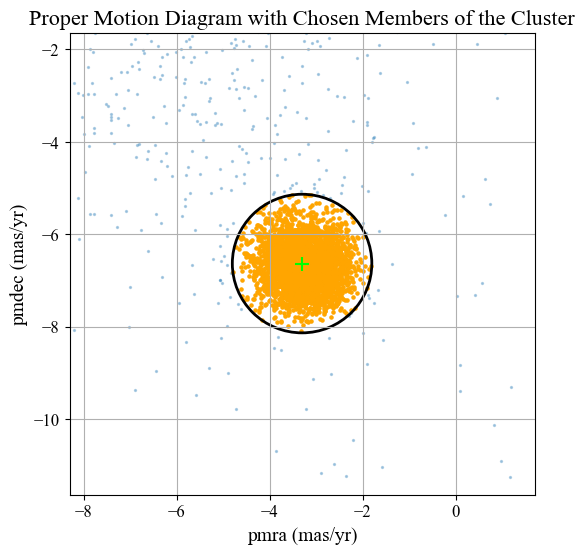

In [687]:
# Plotting the data again
plt.figure(figsize=(6,6))

# All stars
plt.scatter(filtered_data['pmra'], filtered_data['pmdec'], s=2, alpha=0.3)

# Cluster members
plt.scatter(cluster_members['pmra'], cluster_members['pmdec'], s=5, color='orange')

# Cutoff circle
circle = plt.Circle((pmra_center, pmdec_center), radius, color='black', fill=False, linewidth=2)
plt.gca().add_patch(circle)
plt.xlim(pmra_center - 5, pmra_center + 5)
plt.ylim(pmdec_center - 5, pmdec_center + 5)

# Labels
plt.xlabel("pmra (mas/yr)")
plt.ylabel("pmdec (mas/yr)")
plt.title("Proper Motion Diagram with Chosen Members of the Cluster")
plt.scatter(pmra_center, pmdec_center, color='lime', marker='+', s=100, label="Center")
plt.grid()

plt.savefig("Omega_Centauri_Member_Cutoff.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("Omega_Centauri_Member_Cutoff.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

In [688]:
# Saving the star data in a file
cluster_members.to_csv("/Users/ivarismartinez/Desktop/GAIA/OmegaCentauri_cluster_members.csv", index=False)

# Second Part

In [689]:
cluster_members = pd.read_csv('/Users/ivarismartinez/Desktop/GAIA/OmegaCentauri_cluster_members.csv')

In [690]:
# Calculating the BP-RP (color index)
cluster_members["bp_rp"] = (cluster_members["phot_bp_mean_mag"] - cluster_members["phot_rp_mean_mag"])

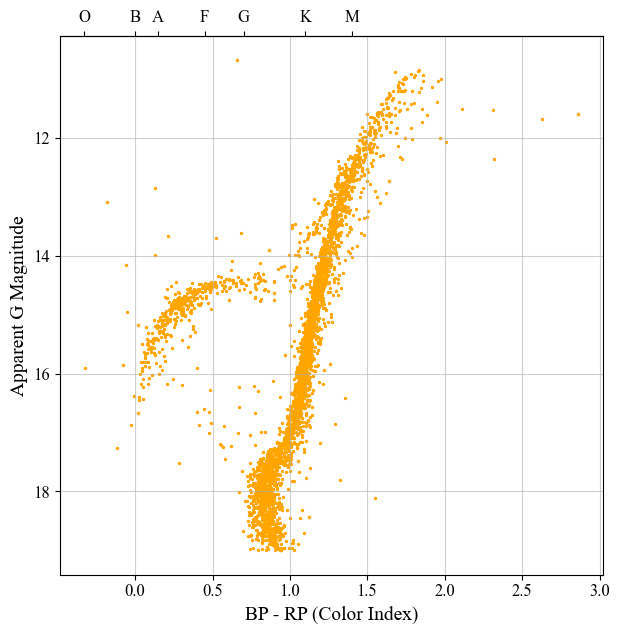

In [691]:
# Plotting Color-Magnitude Diagram vs. G
fig, ax = plt.subplots(figsize=(7,7))

ax.scatter(cluster_members["bp_rp"], cluster_members["phot_g_mean_mag"], s=2, color='orange')
ax.set_xlabel("BP - RP (Color Index)")
ax.set_ylabel("Apparent G Magnitude")
ax.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.4)

# Spectral Types using approximating B-V values to BP-RP
bp_rp_ticks = [-0.33, 0, 0.15, 0.45, 0.70, 1.10, 1.4]
spectral_labels = ["O", "B", "A", "F", "G", "K", "M"]

# Plotting spectral types
secax = ax.secondary_xaxis(
    'top',
    functions=(lambda x: x, lambda x: x))
secax.set_xticks(bp_rp_ticks)
secax.set_xticklabels(spectral_labels)
# secax.set_xlabel("Spectral Type")

# To compare to literature graphs
ax.invert_yaxis()

plt.savefig("Omega_Centauri_Color_Magnitude_Plot.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("Omega_Centauri_Color_Magnitude_Plot.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

In [692]:
# Calculating Absolute Magnitude in the Gaia "G" band
cluster_members["absolute_G"] = (cluster_members["phot_g_mean_mag"] + 5 * np.log10(cluster_members["parallax"]) - 10)

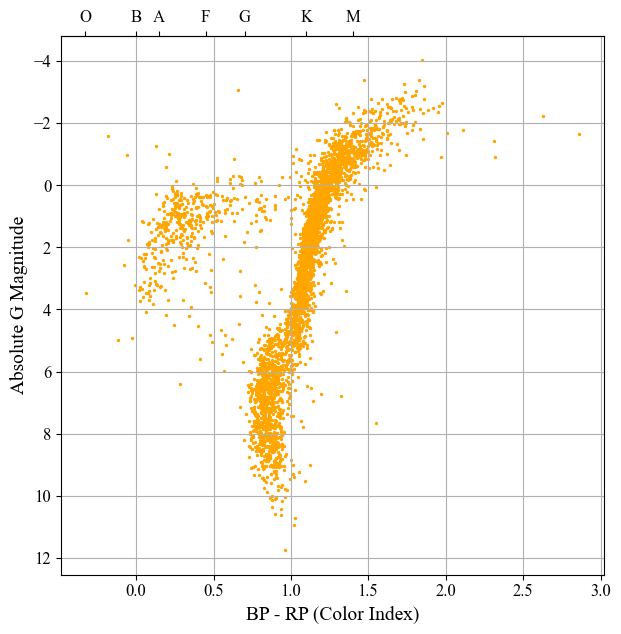

In [694]:
# Plotting Hertzsprung-Russell Diagram
fig, ax = plt.subplots(figsize=(7,7))

ax.scatter(cluster_members["bp_rp"], cluster_members["absolute_G"], s=2, color='orange')

ax.set_xlabel("BP - RP (Color Index)")
ax.set_ylabel("Absolute G Magnitude")
ax.grid(True)

# Plotting spectral types
secax = ax.secondary_xaxis('top', functions=(lambda x: x, lambda x: x))
secax.set_xticks(bp_rp_ticks)
secax.set_xticklabels(spectral_labels)
# secax.set_xlabel("Spectral Type")

# To compare to literature graphs
ax.invert_yaxis()

plt.savefig("Omega_Centauri_Russell_Diagram.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("Omega_Centauri_Russell_Diagram.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

In [695]:
# Saving the new data in a file
cluster_members.to_csv("/Users/ivarismartinez/Desktop/GAIA/OmegaCentauri_cluster_members_new_data.csv", index=False)

# Part 3

In [704]:
cluster_members = pd.read_csv('/Users/ivarismartinez/Desktop/GAIA/OmegaCentauri_cluster_members_new_data.csv')

In [705]:
# Calculating tangential velocities
cluster_members["v_ra"] = 4.74 * cluster_members["pmra"] / cluster_members["parallax"]
cluster_members["v_dec"] = 4.74 * cluster_members["pmdec"] / cluster_members["parallax"]

In [713]:
# Calculating velocity dispersions in each component
sigma_vra = cluster_members["v_ra"].std()
sigma_vdec = cluster_members["v_dec"].std()
print(sigma_vra, sigma_vdec)

# Calculating the one-dimensional velocity dispersion as the average of the two velocity dispersion
sigma_1D = (sigma_vra + sigma_vdec) / 2
print(sigma_1D)

35.793344473159706 71.82278698274612
53.808065727952915


In [720]:
# Changing to km/s
sigma = sigma_1D * 1000 

# Constants
R = 7 * 3.086e16 # taking 10 pc 
G = 6.67e-11

# Mass equation
M = (5 * R * sigma**2) / G

# Changing to solar masses
M_solar = M / 1.989e30
print(M_solar)

23572091.052272774


In [721]:
# Calculating escape velocity in km/s
v_escape = np.sqrt((2 * G * M) / R)
print(v_escape/1000)

170.1560441883773
